# 18장 전이 학습을 통해 딥러닝의 성능 극대화하기

## 1. 소규모 데이터셋으로 만드는 강력한 학습 모델

### 실습: 치매 환자의 뇌인지 일반인의 뇌인지 예측하기

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers

import numpy as np
import matplotlib.pyplot as plt

# 깃허브에 준비된 데이터를 가져옵니다.
!git clone https://github.com/taehojo/data-ch18.git

# 학습셋의 변형을 설정하는 부분입니다.
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.1,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.1,   # 마찬가지로 위, 아래로 이동합니다.
                                  #rotation_range=5,        # 정해진 각도만큼 회전시킵니다. (적용하려면 #표시를 삭제하면 됩니다.)
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  #zoom_range=1.2,          # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  #fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )

train_generator = train_datagen.flow_from_directory(
       './data-ch18/train',   # 학습셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

# 테스트셋은 이미지 부풀리기 과정을 진행하지 않습니다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
       './data-ch18/test',   # 테스트셋이 있는 폴더의 위치입니다.
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')


# 앞서 배운 CNN 모델을 만들어 적용해 보겠습니다.
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

Cloning into 'data-ch18'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (265/265), done.
remote: Total 265 (delta 0), reused 265 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (265/265), 1.86 MiB | 7.06 MiB/s, done.
Found 160 images belonging to 2 classes.
Found 120 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,513 (4.63 MB)

 Trainable params: 1,212,513 (4.63 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# 모델 실행의 옵션을 설정합니다.
model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(learning_rate=0.0002), metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행합니다
history = model.fit(
       train_generator,
       epochs=100,
       validation_data=test_generator,
       validation_steps=10,
       callbacks=[early_stopping_callback])

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.4938 - loss: 0.6977 - val_accuracy: 0.6400 - val_loss: 0.6907
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.4875 - loss: 0.7020 - val_accuracy: 0.5200 - val_loss: 0.6876
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.5125 - loss: 0.6918 - val_accuracy: 0.4800 - val_loss: 0.6919
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.5188 - loss: 0.6905 - val_accuracy: 0.4800 - val_loss: 0.6847
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 324ms/step - accuracy: 0.6812 - loss: 0.6568 - val_accuracy: 0.5400 - val_loss: 0.6866
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.6125 - loss: 0.6498 - val_accuracy: 0.6800 - val_loss: 0.5794
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 312ms/step - accuracy: 0.5813 - loss: 0.6447 - val_accuracy: 0.7600 - val_loss: 0.6044
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.6750 - loss: 0.5813 - val_a

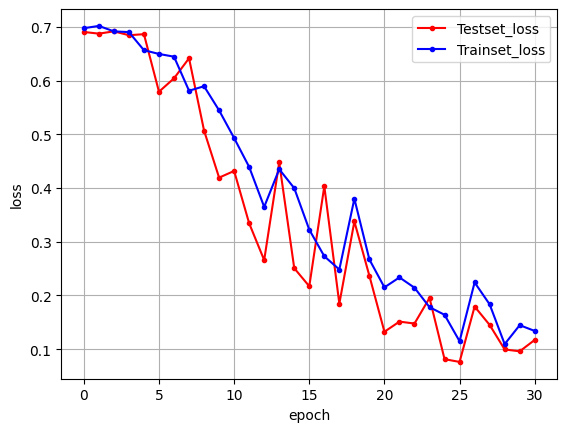

In [3]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 2. 전이 학습으로 모델 성능 극대화하기

### 실습: 전이 학습 실습하기

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Input, models, layers, optimizers, metrics
from tensorflow.keras.layers import Dense, Flatten, Activation, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# 학습셋의 변형을 설정하는 부분입니다.
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지의 크기를 설정합니다.
                                  horizontal_flip=True,     # 수평 대칭 이미지를 50% 확률로 만들어 추가합니다.
                                  width_shift_range=0.1,    # 전체 크기의 15% 범위에서 좌우로 이동합니다.
                                  height_shift_range=0.1,   # 마찬가지로 위, 아래로 이동합니다.
                                  #rotation_range=5,        # 정해진 각도만큼 회전시킵니다.
                                  #shear_range=0.7,         # 좌표 하나를 고정시키고 나머지를 이동시킵니다.
                                  #zoom_range=1.2,          # 확대 또는 축소시킵니다.
                                  #vertical_flip=True,      # 수직 대칭 이미지를 만듭니다.
                                  #fill_mode='nearest'      # 빈 공간을 채우는 방법입니다. nearest 옵션은 가장 비슷한 색으로 채우게 됩니다.
                                  )


train_generator = train_datagen.flow_from_directory(
       './data-ch18/train',
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

# 테스트셋의 정규화를 설정합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
       './data-ch18/test',
       target_size=(150, 150),
       batch_size=5,
       class_mode='binary')

# VGG16 모델을 불러옵니다.
transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model.trainable = False
transfer_model.summary()

# 우리의 모델을 설정합니다.
finetune_model = models.Sequential()
finetune_model.add(transfer_model)
finetune_model.add(Flatten())
finetune_model.add(Dense(64))
finetune_model.add(Activation('relu'))
finetune_model.add(Dropout(0.5))
finetune_model.add(Dense(1))
finetune_model.add(Activation('sigmoid'))
finetune_model.summary()

Found 160 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,239,105 (58.13 MB)

 Trainable params: 524,417 (2.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
# 모델의 실행 옵션을 설정합니다.
finetune_model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(learning_rate=0.0002), metrics=['accuracy'])

# 학습의 조기 중단을 설정합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행합니다.
history = finetune_model.fit(
       train_generator,
       epochs=20,
       validation_data=test_generator,
       validation_steps=10,
       callbacks=[early_stopping_callback])

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6000 - loss: 0.7818 - val_accuracy: 0.6400 - val_loss: 0.5678
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7625 - loss: 0.5394 - val_accuracy: 0.8600 - val_loss: 0.4328
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7250 - loss: 0.5109 - val_accuracy: 0.9400 - val_loss: 0.3720
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8562 - loss: 0.3861 - val_accuracy: 0.9400 - val_loss: 0.3328
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8625 - loss: 0.3581 - val_accuracy: 0.9000 - val_loss: 0.3112
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8938 - loss: 0.3248 - val_accuracy: 0.8600 - val_loss: 0.3163
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9250 - loss: 0.2513 - val_accuracy: 0.9200 - val_loss: 0.2422
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8875 - loss: 0.2648 - val_accuracy: 0.9000 - val_loss:

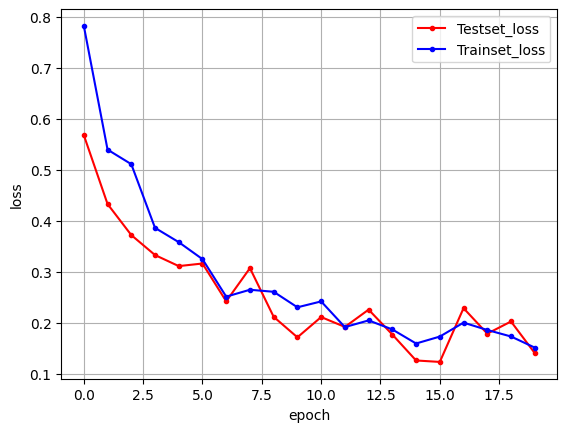

In [6]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

### 모델 성능 평가 및 시각화

24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9667 - loss: 0.1364
## evaluation loss and metrics ##
[0.13644462823867798, 0.9666666388511658]


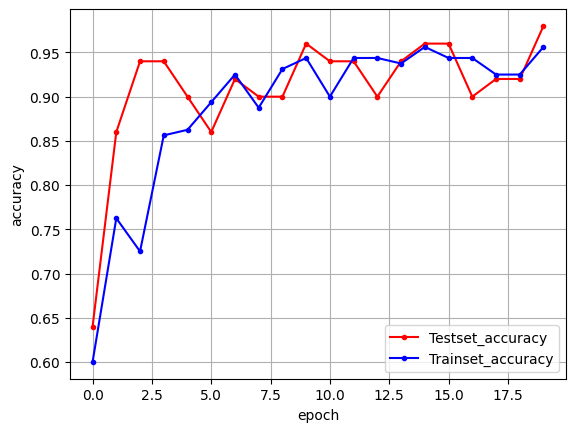

In [7]:
# 모델 성능을 평가합니다.
loss_and_metrics = finetune_model.evaluate(test_generator, steps=len(test_generator))
print('## evaluation loss and metrics ##')
print(loss_and_metrics)

# 검증셋과 학습셋의 정확도를 저장합니다.
y_vacc = history.history['val_accuracy']
y_acc = history.history['accuracy']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_acc))
plt.plot(x_len, y_vacc, marker='.', c="red", label='Testset_accuracy')
plt.plot(x_len, y_acc, marker='.', c="blue", label='Trainset_accuracy')

# 그래프에 그리드를 주고 레이블을 표시합니다.
plt.legend(loc='lower right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

### 파라미터와 하이퍼 파라미터의 차이점

*   **파라미터 (Parameters)**:
    *   모델이 **데이터로부터 학습**하는 내부적인 변수들을 의미합니다.
    *   예시: 신경망의 **가중치(weights)**와 **편향(biases)**.
    *   이러한 파라미터들은 훈련 과정 중에 최적화됩니다.

*   **하이퍼 파라미터 (Hyperparameters)**:
    *   모델의 학습 과정이나 구조를 **수동으로 설정**하는 외부적인 변수들을 의미합니다.
    *   예시: **학습률(learning rate)**, **배치 크기(batch size)**, **에포크(epochs) 수**, **드롭아웃 비율(dropout rate)**, **신경망의 층(layer) 수**, **각 층의 뉴런(neuron) 수**, **활성화 함수(activation function)**, **옵티마이저(optimizer)의 종류**.
    *   하이퍼 파라미터는 모델 훈련 전에 설정되며, 모델의 성능에 큰 영향을 미칩니다. 일반적으로 시행착오, 경험, 또는 자동화된 튜닝 기법(그리드 서치, 랜덤 서치 등)을 통해 최적의 값을 찾습니다.

### 성능 개선을 위한 하이퍼 파라미터 튜닝

이제 모델의 성능을 개선하기 위해 하이퍼 파라미터를 튜닝할 수 있습니다. 가장 먼저 시도할 수 있는 것은 **학습률 (learning rate)** 조정입니다. 현재 학습률은 `0.0002`로 설정되어 있습니다. 이 값을 변경하여 모델의 학습 속도에 어떤 영향을 미치는지 확인할 수 있습니다.

예를 들어, 학습률을 더 높이거나 낮춰 볼 수 있습니다.

다른 하이퍼 파라미터들도 튜닝할 수 있습니다:

*   **에포크(Epochs) 수**: 현재 20 에포크로 설정되어 있지만, 조기 종료가 발동하여 20 에포크 이전에 멈출 수 있습니다. 더 많은 에포크를 시도하거나, 조기 종료 `patience` 값을 조정할 수 있습니다.
*   **배치 크기(Batch size)**: 현재 5로 설정되어 있습니다. 이 값을 변경하여 모델이 한 번에 처리하는 데이터 양을 조절할 수 있습니다.
*   **드롭아웃 비율(Dropout rate)**: 현재 0.5로 설정되어 있습니다. 이 값을 변경하여 과적합을 제어할 수 있습니다.
*   **옵티마이저(Optimizer)**: `Adam` 대신 `RMSprop` 또는 `SGD`와 같은 다른 옵티마이저를 시도할 수 있습니다.
*   **모델 아키텍처**: `Dense` 레이어의 유닛 수, `Conv2D` 레이어의 필터 수 등 모델의 구조를 변경할 수도 있습니다.

어떤 하이퍼 파라미터부터 튜닝을 시작해 볼까요? 아니면 특정 하이퍼 파라미터를 변경하는 코드를 직접 생성해 드릴까요?

### 하이퍼 파라미터 튜닝 시도 1: 학습률 (Learning Rate) 변경

이전 학습률 `0.0002` 대신 `0.001`로 변경하여 모델을 재학습하고 성능 변화를 살펴보겠습니다.

In [ ]:
print('--- 학습률을 0.001로 변경하여 모델 재컴파일 및 재학습 ---')

# 새로운 학습률 설정
new_learning_rate = 0.001

# 모델 재컴파일 (옵티마이저의 학습률만 변경)
finetune_model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(learning_rate=new_learning_rate), metrics=['accuracy'])

# 모델 재학습 (새로운 history 객체에 저장)
history_lr_tuned = finetune_model.fit(
       train_generator,
       epochs=20, # 에포크 수는 이전과 동일하게 유지하여 비교
       validation_data=test_generator,
       validation_steps=10,
       callbacks=[early_stopping_callback]) # 조기 종료 콜백은 그대로 사용

--- 학습률을 0.001로 변경하여 모델 재컴파일 및 재학습 ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7937 - loss: 0.4579 - val_accuracy: 0.7600 - val_loss: 0.6194
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8625 - loss: 0.2521 - val_accuracy: 0.9600 - val_loss: 0.1912
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9125 - loss: 0.1834 - val_accuracy: 0.8400 - val_loss: 0.2555
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9312 - loss: 0.2117 - val_accuracy: 0.9800 - val_loss: 0.0852
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9500 - loss: 0.1608 - val_accuracy: 0.9400 - val_loss: 0.2125
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9062 - loss: 0.2165 - val_accuracy: 0.9200 - val_loss: 0.1886
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9563 - loss: 0.1884 - val_accuracy: 0.9800 - val_loss: 0.0930
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9187 - loss: 0.

### 튜닝된 모델 성능 평가 및 시각화 (학습률: 0.001)

In [ ]:
# 튜닝된 모델 성능을 평가합니다.
loss_and_metrics_lr_tuned = finetune_model.evaluate(test_generator, steps=len(test_generator))
print('## evaluation loss and metrics (Learning Rate 0.001) ##')
print(loss_and_metrics_lr_tuned)

# 검증셋과 학습셋의 정확도를 저장합니다.
y_vacc_lr_tuned = history_lr_tuned.history['val_accuracy']
y_acc_lr_tuned = history_lr_tuned.history['accuracy']

# 그래프로 표현해 봅니다.
x_len_lr_tuned = np.arange(len(y_acc_lr_tuned))
plt.figure(figsize=(10, 6))
plt.plot(x_len_lr_tuned, y_vacc_lr_tuned, marker='.', c="red", label='Testset_accuracy (LR 0.001)')
plt.plot(x_len_lr_tuned, y_acc_lr_tuned, marker='.', c="blue", label='Trainset_accuracy (LR 0.001)')

# 그래프에 그리드를 주고 레이블을 표시합니다.
plt.legend(loc='lower right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Model Accuracy with Learning Rate 0.001')
plt.show()

# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss_lr_tuned = history_lr_tuned.history['val_loss']
y_loss_lr_tuned = history_lr_tuned.history['loss']

# 그래프로 표현해 봅니다.
plt.figure(figsize=(10, 6))
plt.plot(x_len_lr_tuned, y_vloss_lr_tuned, marker='.', c="red", label='Testset_loss (LR 0.001)')
plt.plot(x_len_lr_tuned, y_loss_lr_tuned, marker='.', c="blue", label='Trainset_loss (LR 0.001)')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Model Loss with Learning Rate 0.001')
plt.show()

이번 학습률(`0.001`) 튜닝 결과는 어떠신가요? 이전 (`0.0002`)과 비교하여 어떤 변화가 있는지 확인해 보세요.

이 외에 다른 하이퍼 파라미터를 튜닝해볼 수도 있습니다. 예를 들어:

*   **배치 크기(Batch size)**
*   **에포크(Epochs) 수** (또는 `patience` 값 조정)
*   **드롭아웃 비율(Dropout rate)**
*   **옵티마이저(Optimizer)** 종류

어떤 하이퍼 파라미터 튜닝을 이어서 진행해 볼까요?